In [ ]:
# Import modules
# Clean Data
# Explore Data
# A/B test: t-Test / p-test
# A/B test: Cohen's D
# A/B test: ANOVA
# Conclusion

In [1]:
# Importing our necessary modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf 

from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
# Reading our CSV
data = pd.read_csv("marketing_AB.csv")

In [3]:
# Getting our first look at the Data
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
# Following our first read, I want to rename our columns to replace the spaces with underscores
data.rename(columns={'test group': 'test_group', 
                     'total ads': 'total_ads', 
                     'most ads day': 'most_ads_day', 
                     'most ads hour': 'most_ads_hour',
                     'user id': 'user_id'}, inplace=True)

In [5]:
# Next I want to get an idea on what exactly are the data types I am working with
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user_id        588101 non-null  int64 
 2   test_group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total_ads      588101 non-null  int64 
 5   most_ads_day   588101 non-null  object
 6   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [6]:
# Seeing what we have for null values
data.isnull().sum()

Unnamed: 0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [7]:
# Checking unique values
data['Unnamed: 0'].unique()

array([     0,      1,      2, ..., 588098, 588099, 588100],
      shape=(588101,))

In [8]:
# Checking unique values
data['user_id'].unique()

array([1069124, 1119715, 1144181, ..., 1038442, 1496395, 1237779],
      shape=(588101,))

In [9]:
# Checking unique values
data['test_group'].unique()

array(['ad', 'psa'], dtype=object)

In [10]:
# I want to get rid of this column
data = data.drop(columns=['Unnamed: 0']) 

In [11]:
# Let us convert these data types to make analysis easier
data['converted'] = data['converted'].astype(int)
data['user_id'] = data['user_id'].astype(str)

In [12]:
# Checking out how our data looks. From here we can see a 2.5% conversion rate across both categories. Let's dive deeper!
print(data.describe())

           converted      total_ads  most_ads_hour
count  588101.000000  588101.000000  588101.000000
mean        0.025239      24.820876      14.469061
std         0.156850      43.715181       4.834634
min         0.000000       1.000000       0.000000
25%         0.000000       4.000000      11.000000
50%         0.000000      13.000000      14.000000
75%         0.000000      27.000000      18.000000
max         1.000000    2065.000000      23.000000


In [13]:
# Let's take a look at the value counts for the two groups. The ad group is significantly bigger than the control group. 
print(data['test_group'].value_counts())

test_group
ad     564577
psa     23524
Name: count, dtype: int64


In [14]:
# Now I want to see conversion rate by group. 
# The conversion rate for the ad group is bigger at 2.5%. THe control group is only about 1.78% conversion rate.
print(data.groupby('test_group')['converted'].mean())

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


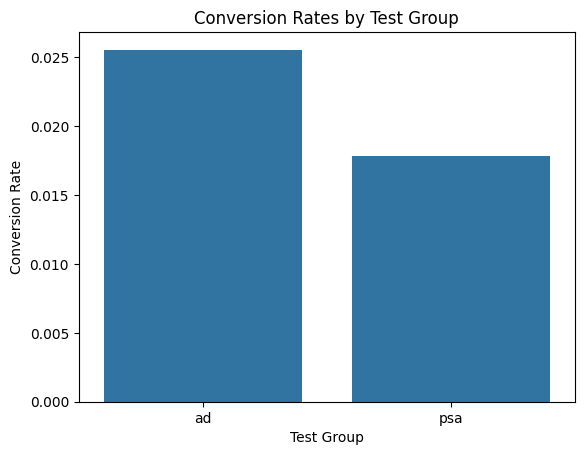

In [28]:
# Let's visualize the last cell.
conversion_rate_by_group = data.groupby('test_group')['converted'].mean()

plt.figure()
sns.barplot(x=conversion_rate_by_group.index, y=conversion_rate_by_group.values)
plt.title('Conversion Rates by Test Group')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate')
plt.show()

<Figure size 640x480 with 0 Axes>

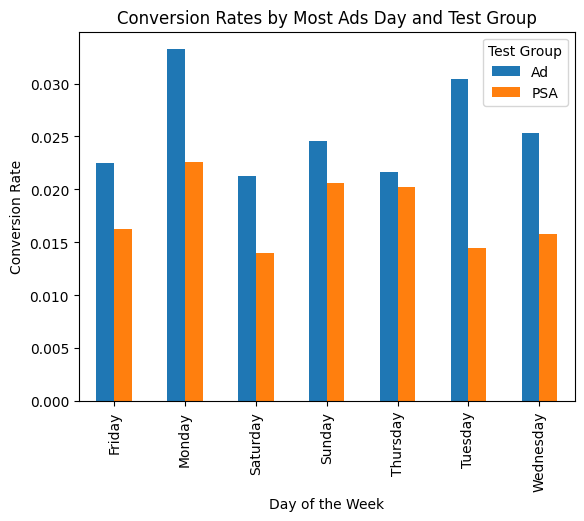

In [29]:
# Now let us visualize conversion rates vs different days of the week
# It does look like the days with the best conversion rates Monday, Tuesday, and Wednesday
conversion_rate_by_day = data.groupby(['most_ads_day', 'test_group'])['converted'].mean().unstack()

plt.figure()
conversion_rate_by_day.plot(kind='bar', stacked=False)
plt.title('Conversion Rates by Most Ads Day and Test Group')
plt.xlabel('Day of the Week')
plt.ylabel('Conversion Rate')
plt.xticks()
plt.legend(title='Test Group', labels=['Ad', 'PSA'])
plt.show()

In [15]:
# Now let us begin work on looking at the statistical analysis. Here we group the ad/psa groups by conversion
ad_group = data[data['test_group']=='ad']['converted']
psa_group = data[data['test_group']=='psa']['converted']

In [16]:
# Making T-stat and p-value 
t_stat, p_value = ttest_ind(ad_group, psa_group, equal_var=False)

In [17]:
# Revealing the t-stat and and p-value
# Null Hypothesis: There is no relationship between ad group and conversion
# For a 95% confidence level, we needed a t-stat of 1.96 or greater 
# Our t-test value is huge, beyond what we need to prove statistical significance 
# Our p-value also proves statistical significance 
print("\nT-Test Results:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")


T-Test Results:
T-Statistic: 8.6572
P-Value: 5.1076e-18


In [18]:
# Let us look at Cohen's D to look at a statistical difference between the means of the groups by measured standard deviation.
# This would measure the practical significance between the two groups
# Null Hypothesis: There is no practical significance between the ad group and conversion status
mean_diff = ad_group.mean() - psa_group.mean()
pooled_std = np.sqrt(((ad_group.var() * (len(ad_group) - 1)) + 
                      (psa_group.var() * (len(psa_group) - 1))) / 
                     (len(ad_group) + len(psa_group) - 2))
cohen_d = mean_diff / pooled_std

In [25]:
# THis is a tad disapointing. For a Cohen's D we would have wanted a an effect size of 0.5 or greater. 
# A Cohen's D for a small effect would be d=0.2d = 0.2
# For a Medium effect: d=0.5d = 0.5
# For a Large effect: d=0.8d = 0.8
# A result of 0.049 indicates that there is a negligible affect.
# So while our t-stat and p-values are statistically significant therefore implying a statistically significant difference
# Cohen's D would tell us that the results are practically insignificant
# Therefore, I cannot reject the Null Hypothesis and would say the results are practically insignificant.
print(f"Cohen's D: {cohen_d}")

Cohen's D: 0.04904561593068278


In [20]:
# Now let us check ANOVA to gauge variance between the days of the week to see if there is a statistically significant difference
# Null Hypthesis: There is no difference between any two days of the week for conversion status
# An F-Stat of 50.3731 means there is strong variation between the days of the week and its impact on conversion 
# The results imply that there is a statistically significant difference between the days of the week the ads are shown
anova_groups = [data[data['most_ads_day'] == day]['total_ads'] for day in data['most_ads_day'].unique()]
f_stat, p_value_anova = f_oneway(*anova_groups)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value_anova:.4e}")

F-Statistic: 50.3731
P-Value: 2.8155e-62


In [21]:
# Now we run Tukey's HSD test to see which day's means are significantly different from each other
tukey = pairwise_tukeyhsd(endog=data['total_ads'],
                          groups=data['most_ads_day'],
                          alpha=0.05)
print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
  Friday    Monday  -1.2836    0.0 -1.8919 -0.6754   True
  Friday  Saturday  -1.3845    0.0  -2.003 -0.7659   True
  Friday    Sunday  -2.2085    0.0 -2.8198 -1.5971   True
  Friday  Thursday  -3.1833    0.0 -3.7992 -2.5673   True
  Friday   Tuesday  -2.6867    0.0  -3.314 -2.0593   True
  Friday Wednesday  -2.0729    0.0  -2.693 -1.4528   True
  Monday  Saturday  -0.1009 0.9992 -0.7286  0.5268  False
  Monday    Sunday  -0.9249 0.0002 -1.5454 -0.3043   True
  Monday  Thursday  -1.8997    0.0 -2.5248 -1.2746   True
  Monday   Tuesday  -1.4031    0.0 -2.0394 -0.7667   True
  Monday Wednesday  -0.7893 0.0041 -1.4185 -0.1601   True
Saturday    Sunday   -0.824 0.0023 -1.4547 -0.1933   True
Saturday  Thursday  -1.7988    0.0  -2.434 -1.1637   True
Saturday   Tuesday  -1.3022    0.0 -1.9484  -0.656   True
Saturday Wedne

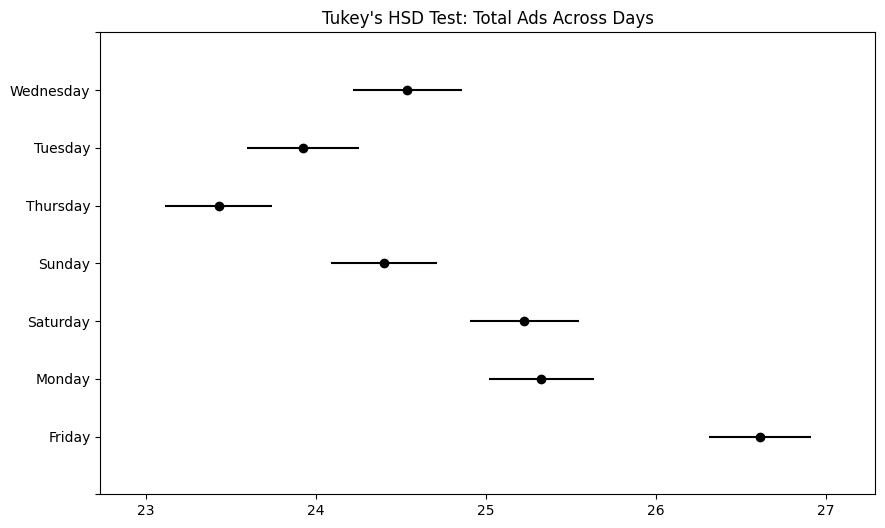

In [22]:
# Visualizing Tukey's HSD
tukey.plot_simultaneous()
plt.title("Tukey's HSD Test: Total Ads Across Days")
plt.show()

In [ ]:
# Key Findings
# Null Hypthesis: There is no difference between any two chosen days of the week for conversion status
# Friday had the biggest differences between days followed by Monday
# There are a few pairings which are not statistically significant. 

In [23]:
# Chi-squared test to test independence of two categorical videos
# Null Hypothesis = no association between conversion and the test groups
# Chi2 Stat = 54 which is very large which does indicate a difference between the test groups
# P-Value = 1.9990e-13 which is exceeds our threshold of 0.05 which also heavily implies a difference
# We can reject the Null Hypothesis and say there is a relationship between test group and conversion

# Create a contingency table
contingency_table = pd.crosstab(data['converted'], data['test_group'])

# Perform Chi-Squared Test
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-Value: {p_chi2:.4e}")
print(f"Degrees of Freedom: {dof}")


Chi-Squared Test Results:
Chi2 Statistic: 54.0058
P-Value: 1.9990e-13
Degrees of Freedom: 1


In [26]:
# A Pearson Correlation measures strength and direction of a linear relationship between two variables. 
# A Spearman Correlation is a non parametric measure of the strengh and direction of a monotonic relationship between two variables.
# Here we measure Total Ads and Conversion Status
# Null Hypothesis: There is no correlation between Total Ads and Conversion Status
# A p-value of 0 for both indicates that we must still reject the null hypothesis
# However, a Spearman coefficient of 0.1927 and Pearson coefficient of 0.2174 indicate a very weak relationship between Total Ads and Conversion Status

pearson_corr, pearson_p_value = pearsonr(data['total_ads'], data['converted'])
spearman_corr, spearman_p_value = spearmanr(data['total_ads'], data['converted'])
print(f"Pearson Correlation: {pearson_corr:.4f}, p-value: {pearson_p_value:.4e}")
print(f"Spearman Correlation: {spearman_corr:.4f}, p-value: {spearman_p_value:.4e}")

Pearson Correlation: 0.2174, p-value: 0.0000e+00
Spearman Correlation: 0.1927, p-value: 0.0000e+00


In [ ]:
# Overall, there is a statistically significant relationship between ad group and conversion status as well as total ads vs conversion status
# We can pinpoint that ads running on Friday would be the most advantageous day to run ads
# However, there is not a practical significance between the two ad groups, the days we run the ads, as well conversion status vs exposure to ads